# Восканян Юрий. КИ22-17/2б
## Практическая работа №2. Сверточные нейронные сети

In [1]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, Nadam
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import VGG16

In [2]:
image_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "./datas"

train_generator = image_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'  
)

val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "evaluation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False 
)

print(f"Классы: {train_generator.class_indices}")

Found 2999 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Классы: {'food': 0, 'non_food': 1}


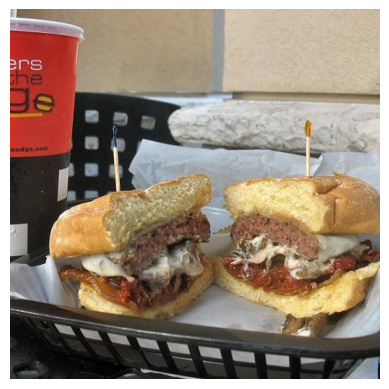

In [ ]:
train_food_dir = os.path.join(DATA_DIR, "training", "food")
filename = os.listdir(train_food_dir)[0]
image_path = os.path.join(train_food_dir, filename)

image = Image.open(image_path).convert("RGB")  
plt.imshow(image)
plt.axis("off")  
plt.show()


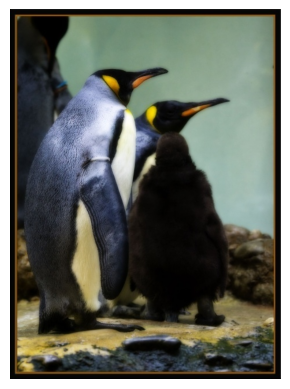

In [ ]:
train_non_food_dir = os.path.join(DATA_DIR, "training", "non_food")
filename = os.listdir(train_non_food_dir)[0]
image_path = os.path.join(train_non_food_dir, filename)

image = Image.open(image_path).convert("RGB")  
plt.imshow(image)
plt.axis("off")  
plt.show()

### Модель 1

In [6]:
inputs = Input(shape=(224, 224, 3))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)  

model1 = Model(inputs=inputs, outputs=outputs)
model1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',   
    patience=3,          
    restore_best_weights=True 
)

history = model1.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping] 
)

test_loss, test_acc = model1.evaluate(test_generator)
print(f"Точность на тестовых данных: {test_acc:.4f}")

model1.summary()

C:\Users\amr\.conda\envs\data_science\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6566 - loss: 1.2966 - val_accuracy: 0.8320 - val_loss: 0.4175
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 66s 702ms/step - accuracy: 0.7934 - loss: 0.4611 - val_accuracy: 0.8280 - val_loss: 0.4005
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 64s 678ms/step - accuracy: 0.8322 - loss: 0.3962 - val_accuracy: 0.8440 - val_loss: 0.3779
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 62s 659ms/step - accuracy: 0.8131 - loss: 0.4485 - val_accuracy: 0.8450 - val_loss: 0.3983
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 66s 701ms/step - accuracy: 0.8497 - loss: 0.4029 - val_accuracy: 0.8560 - val_loss: 0.3427
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 478ms/step - accuracy: 0.8431 - loss: 0.3912
Точность на тестовых данных: 0.8410


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,722,565 (273.60 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,815,044 (182.40 MB)

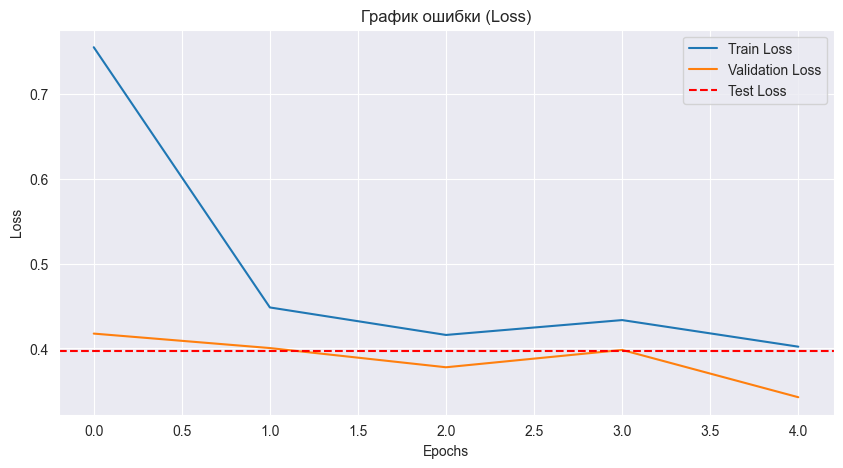

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step


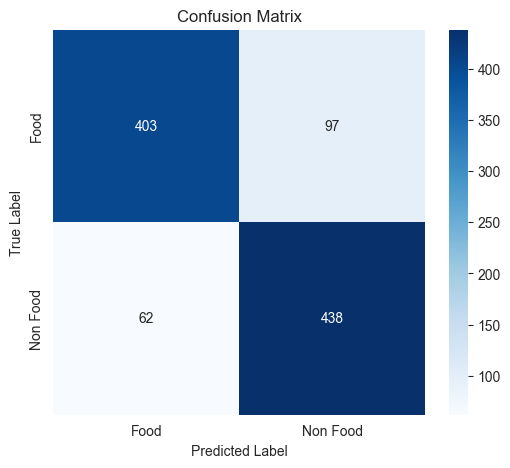

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

test_loss, test_acc = model1.evaluate(test_generator, verbose=0) 
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss') 

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('График ошибки (Loss)')
plt.legend()
plt.show()

y_true = test_generator.classes  
y_pred = model1.predict(test_generator)  
y_pred_labels = (y_pred > 0.5).astype(int)  

cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Food', 'Non Food'], yticklabels=['Food', 'Non Food'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Модель 2

In [8]:
inputs = Input(shape=(224, 224, 3))

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)  

model2 = Model(inputs=inputs, outputs=outputs)

model2.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',   
    patience=3,          
    restore_best_weights=True 
)

history = model2.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping] 
)

test_loss, test_acc = model2.evaluate(test_generator)
print(f"Точность на тестовых данных: {test_acc:.4f}")

model2.summary()

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.6485 - loss: 1.3362 - val_accuracy: 0.5000 - val_loss: 3.7974
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7511 - loss: 0.6682 - val_accuracy: 0.6290 - val_loss: 0.6934
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7802 - loss: 0.5367 - val_accuracy: 0.6100 - val_loss: 1.0672
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8056 - loss: 0.4835 - val_accuracy: 0.8530 - val_loss: 0.3795
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8068 - loss: 0.4317 - val_accuracy: 0.8750 - val_loss: 0.3329
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 485ms/step - accuracy: 0.8200 - loss: 0.4289
Точность на тестовых данных: 0.8410


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,451,717 (295.45 MB)

 Trainable params: 25,817,089 (98.48 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 51,634,180 (196.97 MB)

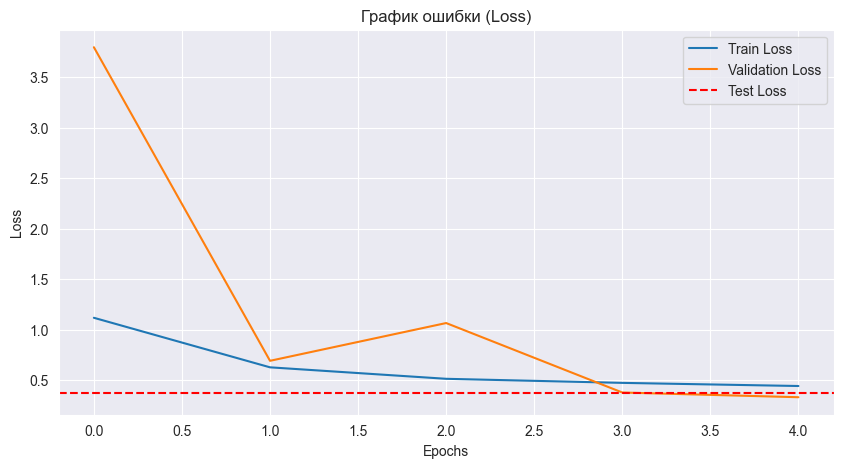

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step


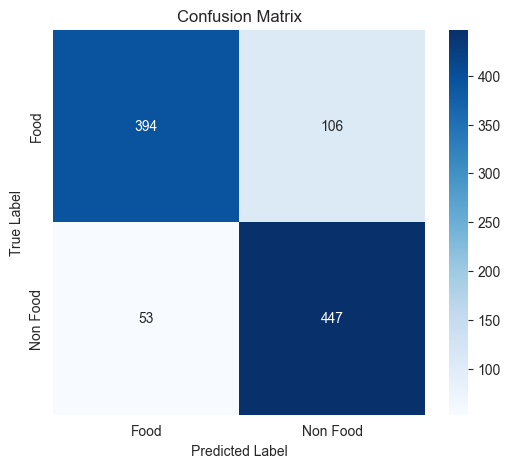

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

test_loss, test_acc = model2.evaluate(test_generator, verbose=0) 
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss') 

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('График ошибки (Loss)')
plt.legend()
plt.show()

y_true = test_generator.classes  
y_pred = model2.predict(test_generator)  
y_pred_labels = (y_pred > 0.5).astype(int)  

cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Food', 'Non Food'], yticklabels=['Food', 'Non Food'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Модель 3

In [10]:
inputs = Input(shape=(224, 224, 3))

x = Conv2D(32, (3,3), activation='swish', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation='swish', padding='same')(x)
x = BatchNormalization()(x)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='swish')(x)  
x = Dropout(0.4)(x) 
x = Dense(64, activation='swish')(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model3 = Model(inputs=inputs, outputs=outputs)

model3.compile(optimizer=Adam(learning_rate=0.0005),  
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',   
    patience=3,
    restore_best_weights=True
)

history = model3.fit(
    train_generator,
    epochs=5,  
    validation_data=val_generator,
    callbacks=[early_stopping]
)

test_loss, test_acc = model3.evaluate(test_generator)
print(f"Точность на тестовых данных: {test_acc:.4f}")

model3.summary()

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.6660 - loss: 0.6080 - val_accuracy: 0.5110 - val_loss: 0.6801
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.7330 - loss: 0.5360 - val_accuracy: 0.5080 - val_loss: 0.6751
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7545 - loss: 0.5189 - val_accuracy: 0.5310 - val_loss: 0.6616
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7680 - loss: 0.4978 - val_accuracy: 0.6430 - val_loss: 0.6148
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7895 - loss: 0.4793 - val_accuracy: 0.6970 - val_loss: 0.5660
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 423ms/step - accuracy: 0.8724 - loss: 0.3846
Точность на тестовых данных: 0.6850


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,869 (425.27 KB)

 Trainable params: 36,225 (141.50 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 72,452 (283.02 KB)

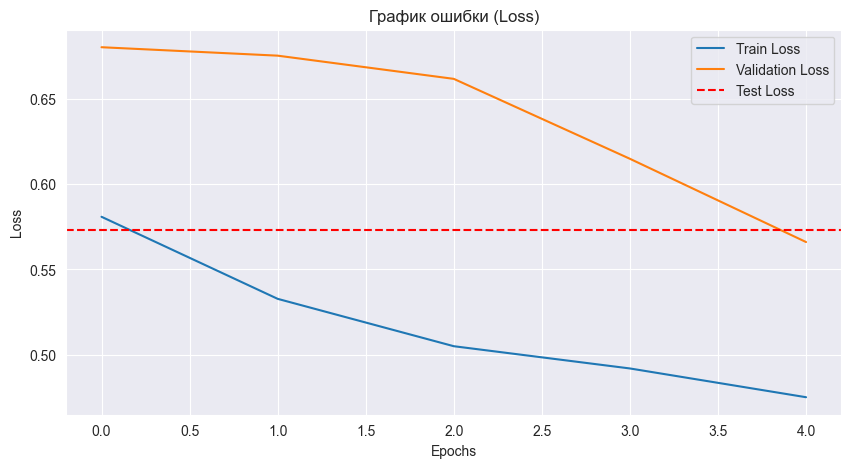

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 424ms/step


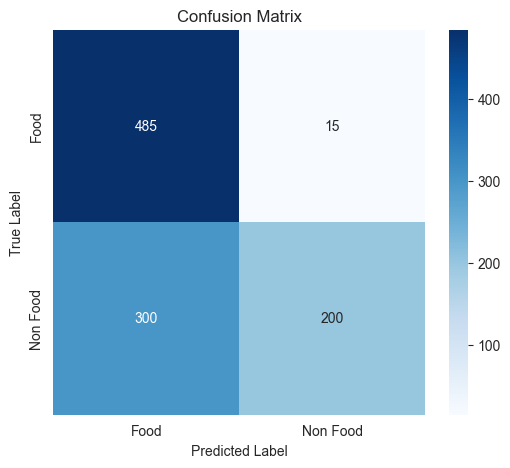

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

test_loss, test_acc = model3.evaluate(test_generator, verbose=0) 
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss') 

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('График ошибки (Loss)')
plt.legend()
plt.show()

y_true = test_generator.classes  
y_pred = model3.predict(test_generator)  
y_pred_labels = (y_pred > 0.5).astype(int)  

cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Food', 'Non Food'], yticklabels=['Food', 'Non Food'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### VGG16

In [12]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False) 

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='swish')(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='swish')(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model_vgg = Model(inputs=inputs, outputs=outputs)

model_vgg.compile(optimizer=Nadam(learning_rate=0.0005),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',   
    patience=3,
    restore_best_weights=True
)

history = model_vgg.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

test_loss, test_acc = model_vgg.evaluate(test_generator)
print(f"Точность на тестовых данных: {test_acc:.4f}")

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.6315 - loss: 0.6348 - val_accuracy: 0.8930 - val_loss: 0.2880
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.8426 - loss: 0.3589 - val_accuracy: 0.9070 - val_loss: 0.2352
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.8834 - loss: 0.2869 - val_accuracy: 0.9280 - val_loss: 0.1866
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.9098 - loss: 0.2414 - val_accuracy: 0.9350 - val_loss: 0.1593
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.9087 - loss: 0.2278 - val_accuracy: 0.9440 - val_loss: 0.1614
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9459 - loss: 0.1532
Точность на тестовых данных: 0.9260


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,936,646 (56.98 MB)

 Trainable params: 73,985 (289.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 147,973 (578.02 KB)

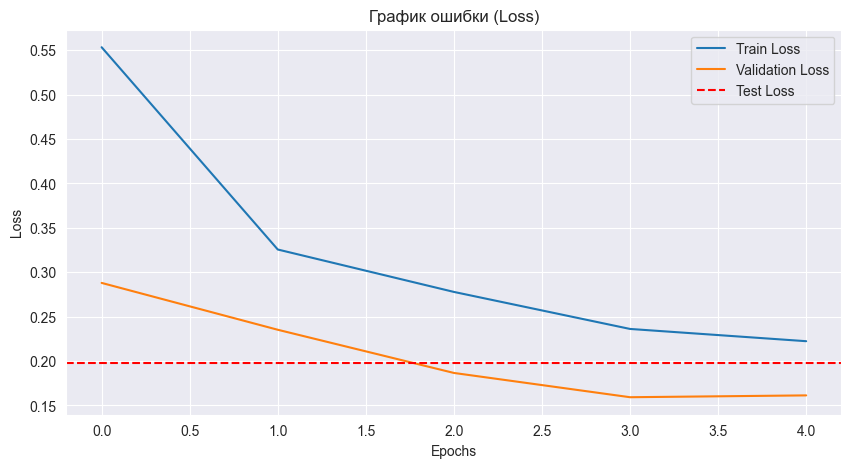

32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step


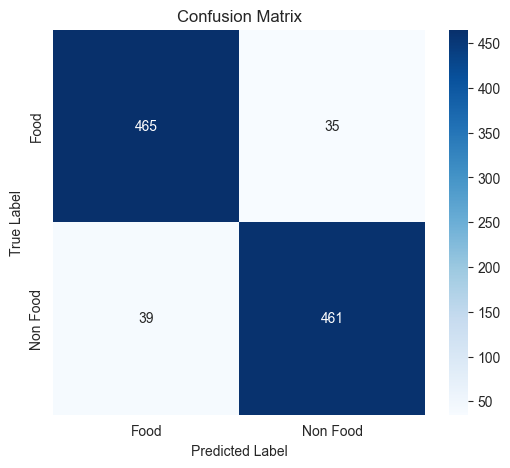

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

test_loss, test_acc = model_vgg.evaluate(test_generator, verbose=0) 
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss') 

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('График ошибки (Loss)')
plt.legend()
plt.show()

y_true = test_generator.classes  
y_pred = model_vgg.predict(test_generator)  
y_pred_labels = (y_pred > 0.5).astype(int)  

cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Food', 'Non Food'], yticklabels=['Food', 'Non Food'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()